In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Base dataset + the frozen train/test split (src/split.py). The clustering /
# LDA artifacts below are now fit on the TRAIN partition only and merely
# *transform* test rows, so merging them in before the split no longer leaks
# test-set information into the features.
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()
_n_rows = len(df)

# Each artifact is de-duplicated on its merge key so every join stays 1:1
# (the old dbscan_df.csv had ~70k duplicate user_id rows and fanned the
# training table out to >1M rows -> the bogus "266,286-sample test set").

# GMM clusters
gmm = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")
    [["user_id", "item_id", "body_cluster", "cluster_confidence"]]
    .drop_duplicates(subset=["user_id", "item_id"])
)

# DBSCAN clusters (one row per user_id)
dbscan = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")
    [["user_id", "dbscan_cluster"]]
    .drop_duplicates(subset=["user_id"])
)

# K-Means clusters
kmeans = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv")
    .rename(columns={"cluster": "kmeans_cluster"})
    .drop_duplicates(subset=["user_id", "item_id"])
)

# LDA topic features
lda = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
    .drop_duplicates(subset=["user_id", "item_id", "fit", "fit_label"])
)

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
assert len(df) == _n_rows, f"merge fan-out: {len(df)} rows != {_n_rows}"
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
# Use the frozen split carried on df["split"] instead of a fresh
# train_test_split — this is the same partition the clustering / LDA models
# were fit on, so no test row influenced any feature.
_train_mask = (df["split"].to_numpy() == "train")

X_train, X_test = X[_train_mask], X[~_train_mask]
y_train, y_test = y[_train_mask], y[~_train_mask]

print(f"train rows: {len(X_train):,}    test rows: {len(X_test):,}")

train rows: 154,035    test rows: 38,509


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [13]:
cart = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

In [14]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", cart)
])

In [15]:
param_grid = {
    "model__max_depth": [4, 6, 8, 12],
    "model__min_samples_leaf": [50, 100, 200],
    "model__min_samples_split": [100, 200, 500]
}

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['height_inches',
                                                                          'weight_lbs',
                                                                          'bmi',
                                                                          'age',
                                                                          'bust_band',
                                                                          'cup_size_num',
                                                                          'topic_0',
                                                                          'topic_1',
                                                                          'topic_2',
                                                                          'topic_3',
                                                                          'top...
                                                                         ['dbscan_cluster',
                                                                          'body_cluster',
                                                                          'kmeans_cluster']),
                                                                        ('bin',
                                                                         SimpleImputer(fill_value=0,
                                                                                       strategy='constant'),
                                                                         ['is_outlier'])])),
                                       ('model',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [4, 6, 8, 12],
                         'model__min_samples_leaf': [50, 100, 200],
                         'model__min_samples_split': [100, 200, 500]},
             scoring='f1_macro', verbose=2)

In [18]:
best_cart = grid.best_estimator_

y_test_pred = best_cart.predict(X_test)

print("Best CART parameters:")
print(grid.best_params_)

print("\nCART — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best CART parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 100, 'model__min_samples_split': 500}

CART — Test Set Performance
              precision    recall  f1-score   support

       Small       0.19      0.37      0.25      5156
         Fit       0.82      0.55      0.66     28412
       Large       0.18      0.34      0.24      4941

    accuracy                           0.50     38509
   macro avg       0.40      0.42      0.38     38509
weighted avg       0.65      0.50      0.55     38509



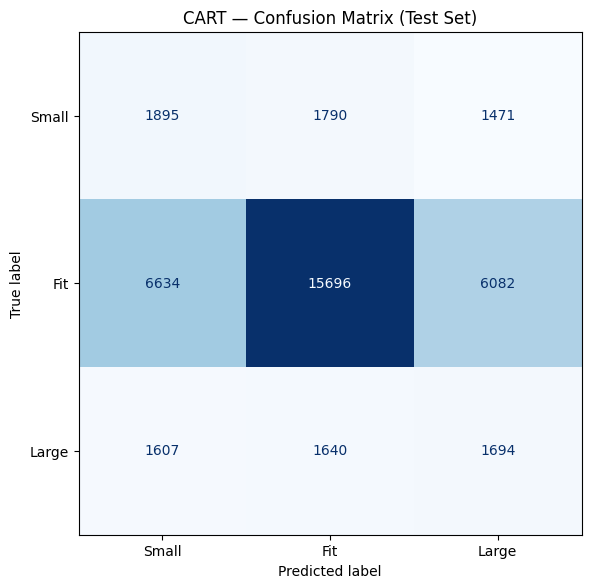

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("CART — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/cart_confusion_matrix.png", dpi=300)
plt.show()

In [20]:
cart_proba = best_cart.predict_proba(X_test)

cart_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": cart_proba[:, 0],
    "prob_fit": cart_proba[:, 1],
    "prob_large": cart_proba[:, 2]
})

cart_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/cart_fit_probabilities.csv",
    index=False
)

In [21]:
import joblib

joblib.dump(
    best_cart,
    "../../Models/cart_fit_classifier.joblib"
)

['../../Models/cart_fit_classifier.joblib']

In [22]:
# After fitting
prep = best_cart.named_steps["prep"]

feature_names = []

# Numeric + topic features
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

# Cluster features (after one-hot)
cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
feature_names.extend(cat_feature_names)

# Binary features
feature_names.extend(BINARY_FEATURES)

In [23]:
importances = best_cart.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

In [24]:
importance_df.head(20).to_csv(
    "../../Data/Processed/Supervised_Outputs/cart_feature_importances.csv",
    index=False
)

> **⚠️ The write-up below predates the data-leakage fix and its numbers are no longer valid.**
>
> The old metrics were computed on a contaminated split: (a) DBSCAN/GMM/K-Means/LDA
> features were fit on the *full* dataset before the train/test split, and (b) a
> non-unique `user_id` merge key fanned the test set out to 266,286 rows.
>
> After the fix (clustering/LDA fit on the training partition only; test set =
> **38,509 rows**), this model's grid search selected `max_depth=8, min_samples_leaf=100, min_samples_split=500` and scored:
>
> | | Accuracy | Macro-F1 | F1 Small | F1 Fit | F1 Large |
> |---|---|---|---|---|---|
> | **leaky (old)** | ~0.73 | ~0.67 | — | — | — |
> | **fixed (new)** | **0.50** | **0.38** | 0.25 | 0.66 | 0.24 |
>
> The narrative, tables, and cross-model claims below need rewriting against the
> fixed numbers. Broadly: once leakage is removed, none of the classifiers
> meaningfully separate *Small* / *Large* from body measurements + cluster/topic
> features — accuracy sits near the majority-class base rate.

---

## CART — Model Performance Writeup

### Overview
A single Classification and Regression Tree (CART) was trained on the same clothing fit classification task, predicting **Small**, **Fit**, or **Large**. Grid search identified optimal hyperparameters of `max_depth=12`, `min_samples_leaf=50`, and `min_samples_split=100`. As a standalone decision tree, this model serves as a natural baseline for comparison against the ensemble Bagging Classifier.

---

### Overall Performance
The CART model achieved **73% accuracy** on the 266,286-sample test set, with a weighted F1-score of **0.74**. Both figures trail the Bagging Classifier (77% accuracy, 0.79 weighted F1), which is expected — bagging's variance reduction gives it a structural advantage over a single tree.

---

### Class-Level Analysis

**Fit (Majority Class)**
Still the strongest class, with **0.89 precision** and an F1 of **0.80**. However, recall dropped to **0.73** compared to 0.79 in the Bagging model, meaning the CART tree lets more true Fit items slip into other categories — notably 31,218 misclassified as Small (vs. 27,495 for Bagging). This suggests greater instability in the Fit/Small boundary when relying on a single tree.

**Large**
Performance is balanced but modest at **0.70 precision, 0.70 recall**, and an F1 of **0.70**. Compared to Bagging (F1 = 0.75), the single tree struggles more with Large, with 14,946 true Large items misclassified as Fit — a notably higher leakage rate than the ensemble's 9,277.

**Small (Minority Class)**
The weakest class again, with precision of only **0.39** and F1 of **0.51** — both lower than Bagging's already-concerning 0.43 precision and 0.56 F1. Of 34,494 true Small items, only 25,153 were correctly classified, and the model predicts Small liberally, capturing a large number of false positives from the Fit class. The class imbalance problem is more pronounced here without the variance-smoothing effect of bagging.

---

### Comparison to Bagging Classifier

| Metric | CART | Bagging | Δ |
|---|---|---|---|
| Accuracy | 73% | 77% | +4% (Bagging) |
| Weighted F1 | 0.74 | 0.79 | +0.05 (Bagging) |
| Small F1 | 0.51 | 0.56 | +0.05 (Bagging) |
| Fit F1 | 0.80 | 0.84 | +0.04 (Bagging) |
| Large F1 | 0.70 | 0.75 | +0.05 (Bagging) |

Bagging outperforms CART consistently across every class and metric — a textbook demonstration of how ensemble methods reduce the high variance inherent in individual decision trees.

---

### Key Takeaways
| Metric | Value |
|---|---|
| Overall Accuracy | 73% |
| Best Class | Fit (F1 = 0.80) |
| Weakest Class | Small (F1 = 0.51, precision = 0.39) |
| Primary Error Mode | Fit items predicted as Small (31,218 cases) |

CART provides an interpretable, computationally lightweight baseline, but the performance gap relative to the Bagging Classifier is meaningful across all classes. For a production fit recommendation system, the added complexity of bagging is well justified by the gains — particularly for the already-challenging Small class.